In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
import random

sys.path.append('../../')

from src.piece_functions import helix,cast_and_surge,persistent_random_walk,straight_line,generate_random_trajectory
from src.io import save_dataframe

Text(0.5, 0.92, 'cast and surge')

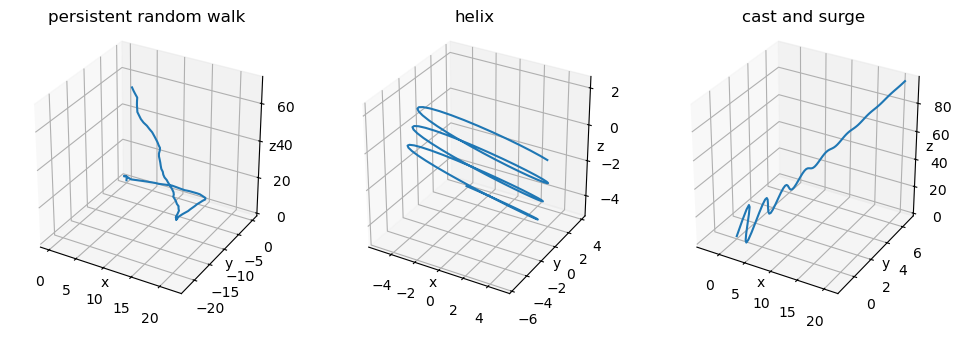

In [2]:
n_steps = 100
A = 1.
B = 1.
w = 0.01
step_size=1
#x, y, z = periodic_behavior_3d([0,0,0], n_steps, A=A, B=B, w=w, dt=step_size)
#x,y,z = cast_and_surge_3d([0,0,0],60,A0=5,decay=0.05,freq=0.5)

fig,ax = plt.subplots(ncols=3, figsize=(12,4),subplot_kw={'projection':'3d'})

x,y,z = persistent_random_walk([0.,0.,0.],n_steps=n_steps,turn_std=np.pi/10)
ax[0].plot(x,y,z)

x,y,z = helix([0.,0.,0.],n_steps=n_steps)
ax[1].plot(x,y,z)

x,y,z = cast_and_surge([0.,0.,0.],n_steps=n_steps)
ax[2].plot(x,y,z)

for i in range(3):
    ax[i].set_xlabel('x',labelpad=-15)
    ax[i].set_ylabel('y',labelpad=-15)
    ax[i].set_zlabel('z',labelpad=-15)
    #ax[i].set_xticklabels([])
    #ax[i].set_yticklabels([])
    #ax[i].set_zticklabels([])
    ax[i].grid(True)
    ax[i].set_box_aspect([1, 1, 1])
ax[0].set_title('persistent random walk')
ax[1].set_title('helix')
ax[2].set_title('cast and surge')

#fig.savefig('stereotypes.svg')

In [2]:
ttot = 2000
mvt_types = ['straight','persistent_random_walk','helix','persistent_random_walk','cast_and_surge']
mvt_args = {'straight':{'n_steps':50,'step':2.,'distrib':'uniform'},'helix':{'radius':5,'pitch':5.,'distrib':'uniform'},'cast_and_surge':{'A0':10,'decay':0.025,'distrib':'unform'},'persistent_random_walk':{'turn_std':np.pi/5,'distrib':'uniform'}}
trj, move_names = generate_random_trajectory(total_steps = ttot,
                                                step_size=1.,
                                                mvt_types = mvt_types,
                                                mvt_args=mvt_args)

In [3]:
trj.shape

(2000, 3)

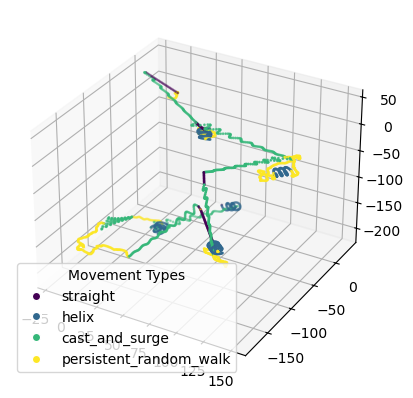

In [ ]:
cmap = colormaps['viridis']
clr_dict ={'straight':cmap(0.),'helix':cmap(0.333),'cast_and_surge':cmap(0.666),'persistent_random_walk':cmap(1.)}
color_code = np.array([clr_dict[mv] for mv in move_names])
fig,ax = plt.subplots(subplot_kw={'projection':'3d'})
ax.scatter(trj[:,0],trj[:,1],trj[:,2],c=color_code,s=1)


legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=key,
           markerfacecolor=color, markersize=6)
    for key, color in clr_dict.items()
]

#ax.legend(handles=legend_elements, title="Movement Types")
#fig.savefig('trajectory_example.svg',bbox_inches='tight')

In [5]:
generate_random_trajectory(total_steps = ttot,
                                                    step_size=1.,
                                                    mvt_types = mvt_types0,
                                                    mvt_args=mvt_args)

NameError: name 'mvt_types0' is not defined

In [6]:
A = 0.5
ttot = 1000
nsample = 100
trjs,moves = np.zeros((nsample,ttot,3),dtype=float),np.zeros((nsample,ttot),dtype='U25')
mvt_types = ['persistent_random_walk','straight']
mvt_args = {'straight':{'n_steps':10,'step':5.}}

for i in range(nsample):
    noise = np.array([np.random.randint(0,1000,ttot)/1000 * A,np.random.randint(0,1000,ttot)/1000 * A,np.random.randint(0,1000,ttot)/1000 * A]).T

    trjs[i],moves[i] = generate_random_trajectory(total_steps = ttot,step_size=1.,mvt_types = mvt_types,mvt_args=mvt_args)
    trjs[i]+=noise

labels = np.repeat(np.arange(nsample), ttot)
frames = np.tile(np.arange(ttot), nsample)

flat_trjs = trjs.reshape(-1, 3)
flat_moves = [item for sublist in moves for item in sublist]

df = pd.DataFrame(flat_trjs, columns=['x', 'y', 'z'])

df['label'] = labels
df['frame'] = frames
df['move_type'] = flat_moves

save_dataframe(df,"../../data/toy_model/raw/persistent_straight.parquet")

In [4]:
A = 0.1
ttot = 1000
nsample = 100
trjs,moves = np.zeros((nsample,ttot,3),dtype=float),np.zeros((nsample,ttot),dtype='U25')
mvt_types = ['helix','straight']
mvt_args = {'straight':{'n_steps':50,'step':2.},'helix':{'radius':5,'pitch':5.}}

for i in range(nsample):
    noise = np.array([np.random.randint(0,1000,ttot)/1000 * A,np.random.randint(0,1000,ttot)/1000 * A,np.random.randint(0,1000,ttot)/1000 * A]).T

    trjs[i],moves[i] = generate_random_trajectory(total_steps = ttot,step_size=1.,mvt_types = mvt_types,mvt_args=mvt_args)
    trjs[i]+=noise

labels = np.repeat(np.arange(nsample), ttot)
frames = np.tile(np.arange(ttot), nsample)

flat_trjs = trjs.reshape(-1, 3)
flat_moves = [item for sublist in moves for item in sublist]

df = pd.DataFrame(flat_trjs, columns=['x', 'y', 'z'])

df['label'] = labels
df['frame'] = frames
df['move_type'] = flat_moves

save_dataframe(df,"../../data/toy_model/raw/straight_helix.parquet")

In [7]:
A = 0.1
ttot = 1000
nsample = 100
trjs0,moves0 = np.zeros((nsample,ttot,3),dtype=float),np.zeros((nsample,ttot),dtype='U25')
trjs1,moves1 = np.zeros((nsample,ttot,3),dtype=float),np.zeros((nsample,ttot),dtype='U25')
trjs2,moves2 = np.zeros((nsample,ttot,3),dtype=float),np.zeros((nsample,ttot),dtype='U25')

mvt_types0 = ['persistent_random_walk']
mvt_types1 = ['straight','persistent_random_walk','helix','persistent_random_walk','cast_and_surge']
mvt_types2 = ['straight','persistent_random_walk']

mvt_args = {'straight':{'n_steps':50,'step':2.},'helix':{'radius':5,'pitch':5.},'cast_and_surge':{'A0':10,'decay':0.025},'persistent_random_walk':{'turn_std':np.pi/5}}

for i in range(nsample):
    noise = np.array([np.random.randint(0,1000,ttot)/1000 * A,np.random.randint(0,1000,ttot)/1000 * A,np.random.randint(0,1000,ttot)/1000 * A]).T

    trjs0[i],moves0[i] = generate_random_trajectory(total_steps = ttot,step_size=1.,mvt_types = mvt_types0,mvt_args=mvt_args)
    trjs1[i],moves1[i] = generate_random_trajectory(total_steps = ttot,step_size=1.,mvt_types = mvt_types1,mvt_args=mvt_args)
    trjs2[i],moves2[i] = generate_random_trajectory(total_steps = ttot,step_size=1.,mvt_types = mvt_types2,mvt_args=mvt_args)
    trjs0[i]+=noise
    trjs1[i]+=noise
    trjs2[i]+=noise

# Create flattened arrays

labels = np.repeat(np.arange(nsample), ttot)
frames = np.tile(np.arange(ttot), nsample)

flat_trjs0 = trjs0.reshape(-1, 3)
flat_trjs1 = trjs1.reshape(-1, 3)
flat_trjs2 = trjs2.reshape(-1, 3)

flat_moves0 = [item for sublist in moves0 for item in sublist]
flat_moves1 = [item for sublist in moves1 for item in sublist]
flat_moves2 = [item for sublist in moves2 for item in sublist]

# Assemble into DataFrame
df0 = pd.DataFrame(flat_trjs0, columns=['x', 'y', 'z'])
df1 = pd.DataFrame(flat_trjs1, columns=['x', 'y', 'z'])
df2 = pd.DataFrame(flat_trjs2, columns=['x', 'y', 'z'])

df0['label'] = labels
df0['frame'] = frames
df0['move_type'] = flat_moves0

df1['label'] = labels
df1['frame'] = frames
df1['move_type'] = flat_moves1

df2['label'] = labels
df2['frame'] = frames
df2['move_type'] = flat_moves2

In [8]:
save_dataframe(df0,"../../data/toy_model/raw/only_persistent.parquet")
save_dataframe(df1,"../../data/toy_model/raw/stereotypes4.parquet")
save_dataframe(df2,"../../data/toy_model/raw/stereotypes2.parquet")
